## Workflow Notebook <br>
Author: T. Kramer 

**Structure**
1. Clustering
2. Prediction
3. Postprocessing (incl. sTA)
4. PCS

**Library import**

In [1]:
# STANDARD
import os

# DATA SCIENCE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

**Global settings**

In [2]:
uni_font = 'Helvetica'
uni_fontsize = 7
uni_color = 'black'
hfont = {'fontname':uni_font}
mm = 1/(2.54*10)  # millimeters in inches

## 1. Clustering
Classify field study subjects into different offset classes. Analyse distribution of offset classes.

**Input:** Initial dataset: ASHRAE Global Thermal Comfort Database II.<br>

 1. Load dataset(s)
 2. Calculate offset classes
 3. Create offset class columns
 4. Save updated dataset incl. offset class

**Output:** Dataset with added offset class column. 

#### Import field data

In [3]:
# ASHRAE Global Thermal Comfort Database II, original dataset available here: https://github.com/CenterForTheBuiltEnvironment/ashrae-db-II
ashrae = pd.read_pickle('data/field-data/ashrae.pkl') 

# Personalised subset of ASHRAE data (only samples with subject ID)
ashrae_personal_subset = pd.read_pickle('data/field-data/ashrae-personal-subset.pkl')

# Data from previous field study, original dataset available here: https://github.com/t-kramer/paper-field-study-23
field_study = pd.read_pickle('data/field-data/field-study.pkl')

#### Calculate offset classes
**A. Thermal sensation** <br>
Classification is based on a function that relates Thermal Sensation Vote (TSV) to Standard Effective Temperature (SET). The offset from between this function and the actual TSV recorded in field data is then used to calculate the mean offset per subject and classify object into offset classes.


**Deriving SET-TSV function**

Slope = 1.363
Intercept = -13.583
a: -13.583, b:1.363, c:-0.046, d:0.001


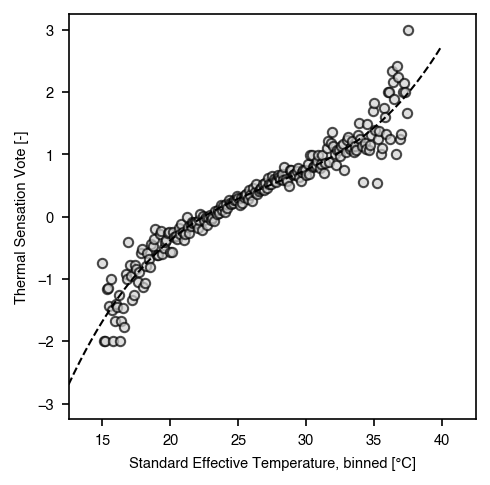

In [4]:
width = 89*mm   # figure width (one-column for journal articles)

data = ashrae   # ASHRAE database II used as basis
bin_feature = 'set'
group_feature = 'thermal_sensation'

data['bin'] = data[bin_feature].round(decimals=1)
data = data.loc[data['bin'].between(15,37.5)]
df = data.groupby(['bin'])[group_feature].mean().reset_index(name='set_tsv')

fig, ax = plt.subplots(figsize = (width,1*width), dpi=150)
ax.scatter(df['bin'], df['set_tsv'], s=20, color='lightgrey',alpha=0.7, edgecolors="k")
d, c, b, a = np.polyfit(df['bin'], df['set_tsv'], deg=3)

xseq = np.linspace(12.5, 40, num=1000)
ax.plot(xseq, a + b * xseq + c * xseq**2 + d * xseq**3, color="k", lw=1, ls='--');

print(f"Slope = {b.round(decimals=3)}")
print(f"Intercept = {a.round(decimals=3)}")
print(f"a: {a.round(decimals=3)}, b:{b.round(decimals=3)}, c:{c.round(decimals=3)}, d:{d.round(decimals=3)}")

plt.yticks(font=uni_font, fontsize=uni_fontsize)
plt.xticks(ticks=[15,20,25,30,35,40],font=uni_font, fontsize=uni_fontsize)

ax.set_xlabel('Standard Effective Temperature, binned [°C]', font=uni_font, fontsize=uni_fontsize)
ax.set_ylabel('Thermal Sensation Vote [-]', font=uni_font, fontsize=uni_fontsize)
ax.set_ylim(-3.25,3.25)
ax.set_xlim(12.5,42.5)

plt.show()

**Computing offset for each sample**

In [5]:
# function
def compute_offset(df, set_key, tsv_key):

    parameters = [-13.58271,
                  1.36316,
                  -0.04643,
                  0.00056]
    
    df['set_tsv'] = parameters[0] + parameters[1] * df[set_key] + parameters[2] * df[set_key]**2 + parameters[3] * df[set_key]**3
    df['ts_offset'] = df[tsv_key] - df['set_tsv']



# apply function
for df in [ashrae_personal_subset, field_study]:
    df = compute_offset(df, 'set', 'thermal_sensation')

**Computing mean offset per subject**

In [6]:
# function
def generate_mean_personal_offset(df, subject_id_key):
    
    mean_ts_offset = df.groupby(subject_id_key)['ts_offset'].mean()
    df['personal_mean_ts_offset'] = df[subject_id_key].apply(lambda x: mean_ts_offset[x])


# apply function
for df in [ashrae_personal_subset, field_study]:
    df = generate_mean_personal_offset(df, 'subject_id')

**Plotting distribution of personal offset in histogram**

(array([0.00653814, 0.03956412, 0.17091366, 0.52313495, 0.19685666,
       0.05632858, 0.00666387]), array([-3.5, -2.5, -1.5, -0.5,  0.5,  1.5,  2.5,  3.5]), [<matplotlib.patches.Polygon object at 0x7f7dfc9bc9a0>])


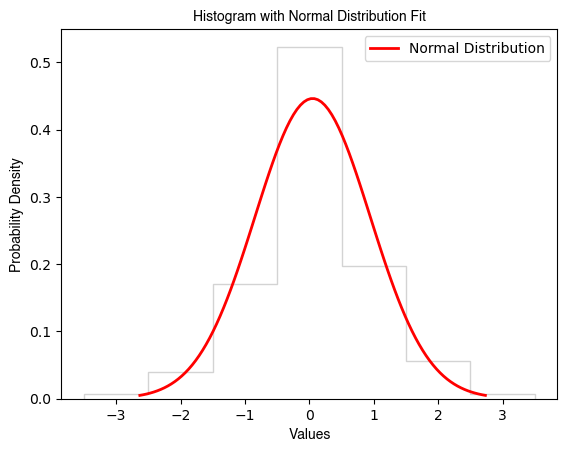

In [7]:
from scipy.stats import norm

bins = [-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5]

counts = plt.hist(ashrae_personal_subset['personal_mean_ts_offset'], bins=bins, histtype='step',color='lightgrey', density=True)

mu = ashrae_personal_subset['personal_mean_ts_offset'].mean()
sigma = ashrae_personal_subset['personal_mean_ts_offset'].std()
x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal Distribution')

plt.xlabel('Values',font=uni_font)
plt.ylabel('Probability Density',font=uni_font)
plt.legend()
plt.title('Histogram with Normal Distribution Fit', font=uni_font)

print(counts)

plt.show()

**Creating offset classes** <br>
Based on the histogram above, it was assumed that grouping subjects into five classes describing their offset from the overall pattern in the data. Bins were chosen as reflected in function below: [-3, -1.5, -0.5, 0.5, 1.5, 3]. Labels for the resulting classes were the following: [-2, -1, 0, 1, 2].

In [8]:
# function
def ts_offset_grouping(row,col):
    '''Create offset classes'''

    if row[col] <= -1.5:
        return -2
    elif row[col] > -1.5 and row[col] <= -0.5:
        return -1
    elif row[col] > -0.5 and row[col] <= 0.5:
        return 0
    elif row[col] > 0.5 and row[col] <= 1.5:
        return 1
    elif row[col] > 1.5:
        return 2
    else:
        return None
    

# apply function
for df in [ashrae_personal_subset, field_study]:
    df['ts_offset_class'] = df.apply(lambda row: ts_offset_grouping(row, 'personal_mean_ts_offset'), axis=1)

Quick look at distribution.

In [9]:
ashrae_personal_subset['ts_offset_class'].value_counts(normalize=True)

 0.0    0.523135
 1.0    0.196857
-1.0    0.170914
 2.0    0.062992
-2.0    0.046102
Name: ts_offset_class, dtype: float64

**B. Thermal Preference** <br>
Offset classification based on **thermal preference** is also tested. The idea is the same, except that TSV is replaced by thermal preference vote (TPV). Also, the number of classes should probably be reduced to 3, because there are only three classes for TPV as well.

Slope = -0.322
Intercept = 4.011
a: 4.011, b:-0.322, c:0.008, d:-0.0


/var/folders/1w/rd04svb56878ny53bl_ftyz40000gn/T/ipykernel_54233/335868921.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['bin'] = (data[bin_feature] / 0.25).round() * 0.25


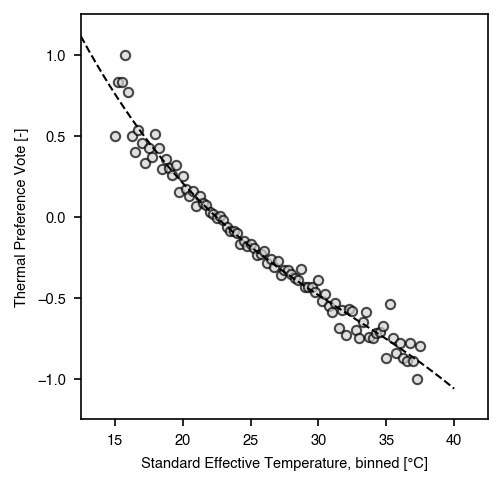

In [10]:
data = ashrae.dropna(subset=['thermal_preference'])   # ASHRAE database II used as basis

group_feature = 'thermal_preference'

data['bin'] = (data[bin_feature] / 0.25).round() * 0.25
data = data.loc[data['bin'].between(15,37.5)]
df = data.groupby(['bin'])[group_feature].mean().reset_index(name='set_tpv')

fig, ax = plt.subplots(figsize = (width,1*width), dpi=150)
ax.scatter(df['bin'], df['set_tpv'], s=20, color='lightgrey',alpha=0.7, edgecolors="k")
d, c, b, a = np.polyfit(df['bin'], df['set_tpv'], deg=3)

xseq = np.linspace(12.5, 40, num=1000)
ax.plot(xseq, a + b * xseq + c * xseq**2 + d * xseq**3, color="k", lw=1, ls='--');

print(f"Slope = {b.round(decimals=3)}")
print(f"Intercept = {a.round(decimals=3)}")
print(f"a: {a.round(decimals=3)}, b:{b.round(decimals=3)}, c:{c.round(decimals=3)}, d:{d.round(decimals=3)}")

plt.yticks(font=uni_font, fontsize=uni_fontsize)
plt.xticks(ticks=[15,20,25,30,35,40],font=uni_font, fontsize=uni_fontsize)

ax.set_xlabel('Standard Effective Temperature, binned [°C]', font=uni_font, fontsize=uni_fontsize)
ax.set_ylabel('Thermal Preference Vote [-]', font=uni_font, fontsize=uni_fontsize)
ax.set_ylim(-1.25,1.25)
ax.set_xlim(12.5,42.5)

plt.show()

Here, steps similar to the ones for TSV could be conducted here. This is skipped for now. 

<br>
Eventually, the updated dataset incl. offset class definitions is stored locally for further use.

In [11]:
ashrae_personal_subset.to_pickle('data/processed/ashrae-personal-subset-incl-offset.pkl')
field_study.to_pickle('data/processed/field-study-incl-offset.pkl')

----
The next step is to train the Machine Learning Model, using the generated offset classes as an input feature. Numerous examples are openly available for how to train ML models in the context of thermal comfort. Therefore, this step is skipped in this notebook. For questions about this step, contact the author.

----

### Prediction

**Library import**

In [12]:
# STANDARD
import json
from joblib import load

# DATA SCIENCE
from numpy import genfromtxt

# MISCELLANEOUS
from epw import epw
from pythermalcomfort.models import pmv, adaptive_ashrae, clo_tout
from pythermalcomfort import psychrometrics

# CUSTOM
# from src.utilities.plot import plot3D

**Import ML model**

In [13]:
lrModel = load('models/lr_pipe.joblib')

# rfModel = load('models/rf_pipe.joblib')

# svcModel = load('models/svc_pipe.joblib')

# stackingModel = load('models/stacking_pipe.joblib')

trainedModel = lrModel


**Simulation data import** <br>
The ML model was trained on the following features: air temperature (ta), relative humidity (rh), radiant temperature (tr), air velocity (vel) and offset class. The simulated data for the required indoor environmental variables was generated using Ladybug Tools and saved as an n-dimensional array. Each row represents a point on a 2-dimensional 1m x 1m grid in the simulated space, each column represent an hour of the year.

In [14]:
environmentalArray = np.load('data/simulation-data/indoor-environment.npy')

ta, rh, tr, vel = np.split(environmentalArray, 4, axis=0)

print(f'Arrays of shape {ta.shape} [r=grid-point, c=hour] imported.')

# variable used to reshape arrays later
grid_length = len(ta)

Arrays of shape (504, 8760) [r=grid-point, c=hour] imported.


In [15]:
weather_file = epw()
weather_file.read(r'data/simulation-data/AUS_QLD_Brisbane.Intl.AP.945780_10_BR_CZ0205_RMY2012C.epw')

# Generate lists of outdoor temperature values
outdoor_temperatures = weather_file.dataframe['Dry Bulb Temperature']
outdoor_temperatures_six_am = outdoor_temperatures[6::24].reset_index()

# create array of dynamic clo values for PMV based on outdoor temperature (6am)
daily_clo_values = clo_tout(tout=outdoor_temperatures_six_am['Dry Bulb Temperature'].to_list())
hourly_clo_values = np.repeat(daily_clo_values, 24)
clo = np.tile(hourly_clo_values, (grid_length, 1))

In [16]:
# Generate arrays for each offset class (required as input for prediction)
classLabels = [-2, -1, 0, 1, 2]
offsetArrays = []

for count, element in enumerate(classLabels):

    offset = np.full(ta.shape, element)
    offsetArrays.append(offset)

**Predict spatial thermal preference**

In [17]:
def predict_spatial_thermal_preference(offsetArrays, environmentalArray, predictionModel):
    
    ta, rh, tr, vel = np.split(environmentalArray, 4, axis=0)
    predictionArrays = [] # list to store the prediction arrays for each offset class

    # loop through offset arrays
    for offsetArray in offsetArrays:

        flattenedSimResults = np.vstack((ta.flatten(), rh.flatten(), tr.flatten(), vel.flatten(), offsetArray.flatten()))
        inputDf = pd.DataFrame(flattenedSimResults.transpose(), columns=['ta','rh','tr','vel','ts_offset_class']).round(1)

        y_proba = predictionModel.predict_proba(inputDf)
        predictionArrays.append(-y_proba[:,0] + y_proba[:,-1])

    # combining the prediction arrays for each offset class
    combinedPrediction = np.array(predictionArrays)

    return combinedPrediction

combinedPrediction = predict_spatial_thermal_preference(offsetArrays, environmentalArray, trainedModel)

# np.save('data/result-arrays/combinedPrediction.npy', combinedPrediction)

In [18]:
# OPTIONAL: Combine individual predictions using weighting factors
# Weighting factors are based on distribution in ASHRAE database II

WEIGHTS = np.array([0.05, 0.2, 0.5, 0.2, 0.05])

weightedPrediction = np.dot(combinedPrediction.transpose(), WEIGHTS)

mlPredictions = weightedPrediction.reshape(grid_length,8760)

**Compute PMV and Adaptive Model for comparison**

In [19]:
# PMV Model

pmvInput = np.vstack((ta.flatten(), rh.flatten(), tr.flatten(), vel.flatten(), clo.flatten()))
pmvDf = pd.DataFrame(pmvInput.transpose(), columns=['ta','rh','tr','vel', 'clo']).round(2)
pmv_array = pmv(pmvDf.ta, pmvDf.tr.round(decimals=1), pmvDf.vel, pmvDf.rh, 1.1, pmvDf.clo, limit_inputs=False).to_numpy()
pmvPredictions = pmv_array.reshape(grid_length,8760)

In [20]:
# Adaptive Comfort Model

dbt = outdoor_temperatures.to_numpy()
dbt_simple = dbt.repeat(repeats=grid_length, axis=0) # repeat outdoor temperature for each grid point

adaptiveInput = np.vstack((ta.flatten(), tr.flatten(), dbt_simple, vel.flatten()))
adaptiveDf = pd.DataFrame(adaptiveInput.transpose(), columns=['ta','tr','dbt','vel']).round(2)
adaptiveDf['top']  = psychrometrics.t_o(adaptiveDf.ta, adaptiveDf.tr, adaptiveDf.vel) # top = operative temperature

# use 80% acceptability as threshold
adaptiveDf['tmp_cmf_80_low'] = adaptive_ashrae(adaptiveDf.ta, adaptiveDf.tr, adaptiveDf.dbt, adaptiveDf.vel, limit_inputs=False)['tmp_cmf_80_low']
adaptiveDf['tmp_cmf_80_up'] = adaptive_ashrae(adaptiveDf.ta, adaptiveDf.tr, adaptiveDf.dbt, adaptiveDf.vel, limit_inputs=False)['tmp_cmf_80_up']

# group Adaptive predictions into 3 classes: cold, neutral, warm
conditions = [
    (adaptiveDf['top'] <= adaptiveDf['tmp_cmf_80_low']),
    (adaptiveDf['top'] > adaptiveDf['tmp_cmf_80_low']) & (adaptiveDf['top'] < adaptiveDf['tmp_cmf_80_up']),
    (adaptiveDf['top'] >= adaptiveDf['tmp_cmf_80_up'])
    ]

values = [1, 0, -1]

adaptiveDf['adaptive'] = np.select(conditions, values)
adaptive_array = adaptiveDf['adaptive'].to_numpy()
adaptivePredictions = adaptive_array.reshape(grid_length,8760)

In [21]:
# OPTIONAL: Save arrays to file

# np.save('data/output/mlPrediction.npy', mlPredictions)
# np.save('data/output/pmvPredictions.npy', pmvPredictions)
# np.save('data/output/adaptivePredictions.npy', adaptivePredictions)

In [24]:
# group PMV and ML predictions into three classes: cold, neutral, warm
choices = [1, -1, 0]

pmvConditions = [pmvPredictions > 0.5, pmvPredictions < -0.5, abs(pmvPredictions) <= 0.5]
pmvBinned = np.select(conditions, choices, default=pmvPredictions) 
pmvBinned = pmvBinned * -1

mlConditions = [mlPredictions > 0.5, mlPredictions < -0.5, abs(mlPredictions) <= 0.5]
mlBinned = np.select(conditions, choices, default=mlPredictions)
mlBinned = mlBinned * -1

ValueError: shape mismatch: objects cannot be broadcast to a single shape

In [26]:
# Generate array of hourly mean prediction in grid
#! Wrap in flexible function
hourly_mean = mlPredictions.mean(axis=0)
hourly_var = mlPredictions.var(axis=0)

# Evaluate using numpy functions
print('ML:')
discomfort_hourly_mean = round(np.count_nonzero((abs(hourly_mean) >= 0.5)) / 8760, ndigits=3)
print(f'Overall discomfort: {discomfort_hourly_mean}')

warm_discomfort = round(np.count_nonzero((hourly_mean <= -0.5)) / 8760, ndigits=3)
print(f'Warm discomfort: {warm_discomfort}')

cold_discomfort = round(np.count_nonzero((hourly_mean >= 0.5)) / 8760, ndigits=3)
print(f'Cold discomfort: {cold_discomfort}')


ML:
Overall discomfort: 0.0
Warm discomfort: 0.0
Cold discomfort: 0.0



### Postprocessing

**Evaluate spatial Thermal Autonomy**


In [31]:
def compute_sta(prediction_array, percentage_area=0.5):
    """
    Computes sTA based on simulated indoor environmental data.

    Args:
        prediction_array (numpy.ndarray): 2D array containing predictions of spatial thermal preference.
        percentage_area (float, optional): Percentage of area threshold for sTA; defaults to 0.5.

    Returns:
        comfort_hours (numpy.ndarray): 2D array containing a boolean comfort prediction for each grid point.
        hourly_autonomy (numpy.ndarray): 1D array where each element represents the hourly sTA.
        spatial_autonomy (float): Annual sTA depending on specified percentage area.
    """

    comfort_hours = np.where(abs(prediction_array) <= 0.5, 1, 0)

    hourly_autonomy = np.sum(comfort_hours, axis=0) / prediction_array.shape[0]
    spatial_autonomy = np.sum( np.where(hourly_autonomy > percentage_area, 1, 0)) / prediction_array.shape[1]

    return spatial_autonomy, hourly_autonomy, comfort_hours


def plot_sta(predictions, width=10):
    """
    Plots spatial Thermal Autonomy.

    Args:
        predictions (numpy.ndarray): A 2D array of predictions (e.g. ML, PMV) to plot.
        width (int, optional): The width of the plot. Defaults to 10.
    """
    plt.figure(figsize=(width,0.5*width), dpi=500)
    plt.imshow(np.sort(predictions, axis=0), cmap='bwr_r',interpolation='bicubic', aspect=2, alpha=0.75, vmax=1,vmin=-1)
    plt.title(f"Model: PMV, spatial Thermal Autonomy: {compute_sta(predictions)[0].round(decimals=2)}", font='Helvetica')
    plt.xlabel("Time [h]")
    plt.ylabel("Grid points [-]")

    xticks = [15.5*24,      #JAN
              (32+15.5)*24, #FEB
              (60+15.5)*24, #etc.
              (91+15.5)*24,
              (15.5+121)*24,
              (15.5+152)*24,
              (15.5+182)*24,
              (15.5+213)*24,
              (15.5+243)*24,
              (15.5+274)*24,
              (15.5+304)*24,
              (15.5+334)*24]
    
    xlabels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    plt.xticks(ticks=xticks,labels=xlabels)

    plt.show()

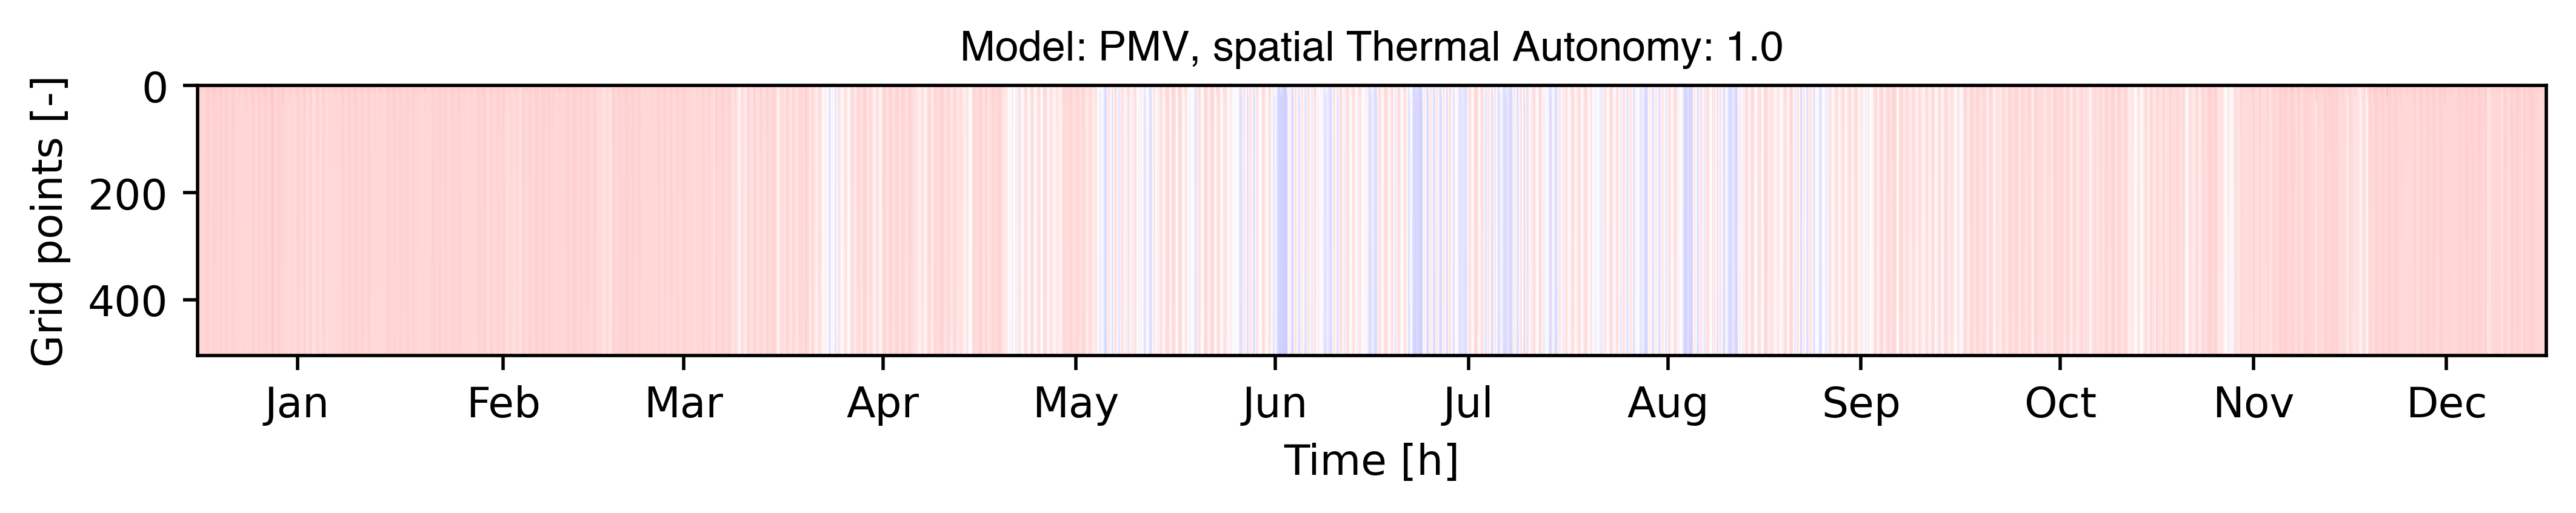

In [32]:
plot_sta(mlPredictions)

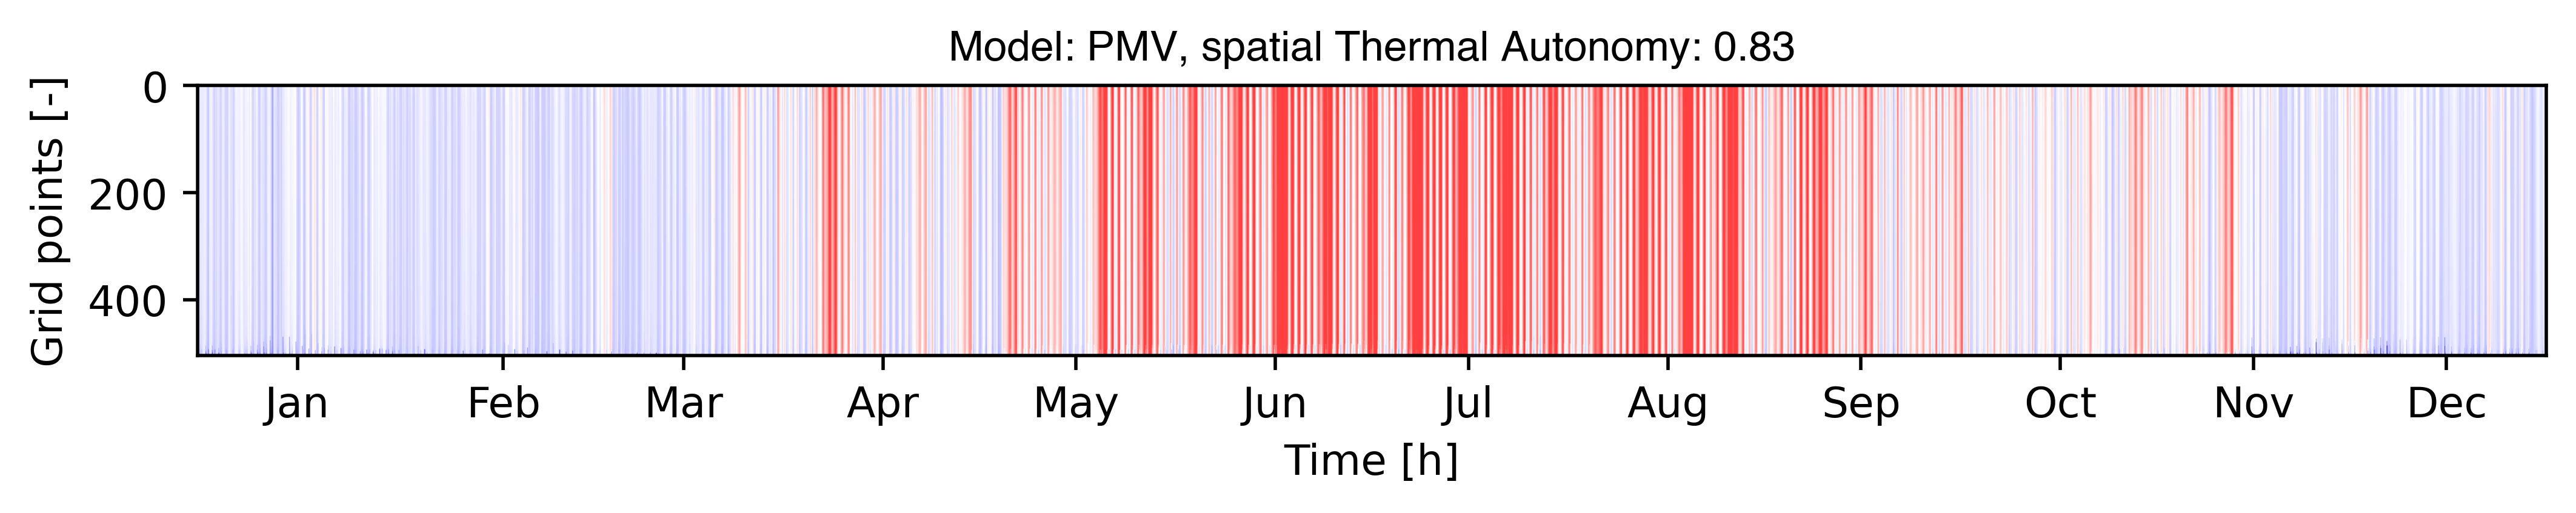

In [33]:
plot_sta(pmvPredictions)

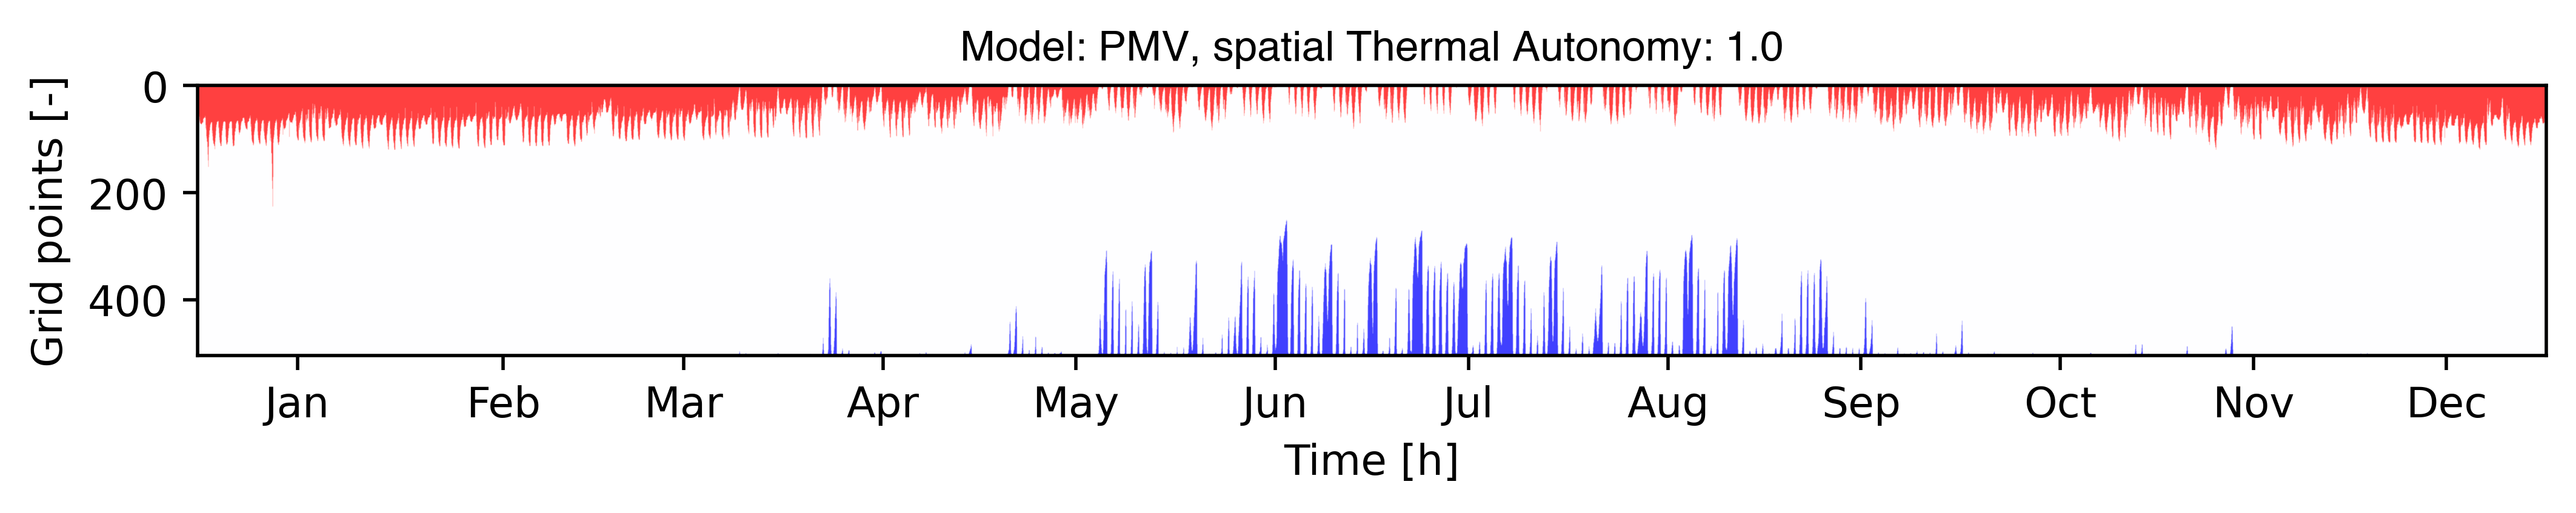

In [34]:
plot_sta(adaptivePredictions)

In [ ]:
# Add sTA, visualsing etc.

### PCS

In [ ]:
# Add PCS definitions and application here.